# 🚀 Tabular AutoML Pipeline — Production Workflow

This notebook orchestrates a **production-grade supervised learning pipeline** using the centralized `AutoMLFactory` engine.
All artifacts (models, plots, MLflow runs, predictions) are routed to a single run directory defined in the configuration.

---

### 📜 The Configuration Ledger (Schema)

| Key | Type | Description | Available Options | Example |
|:---|:---|:---|:---|:---|
| `experiment_name` | `str` | MLflow experiment identifier. | Any string | `"Tabular_V2"` |
| `task_type` | `str` | ML task routing. | `"tabular"` | `"tabular"` |
| `dataset_path` | `str` | Path to cleaned CSV. | Any valid path | `"Dataset/train.csv"` |
| `dataset_path` | `str` | Path to cleaned CSV. | Any valid path | `"Dataset/train.csv"` |
| `test_set` | `str` | Path to pre-split test CSV (optional). | Any valid path, `None` | `"Dataset/test.csv"` |
| `features` | `List[str]` | Columns to use as features. Empty `[]` uses all non-target columns. | List of column names, `[]` | `[]` |
| `exclude_features` | `List[str]` | Columns to explicitly exclude from training. Protected columns (target) are never dropped. | List of column names, `[]` | `["customer_id"]` |
| `target_column` | `List[str]` | Target column name(s). Always a list, even for single-label. | Column name(s) in dataset | `["target"]` |
| `problem_types` | `List[str]` | Problem type(s) per target. Leave `[]` for auto-inference. | `"binary"`, `"multiclass"`, `"regression"` | `[]` |
| `eval_metrics` | `List[str]` | Optimization metric(s). One per target column. | **Binary/Multiclass:** `"f1_macro"`, `"f1_weighted"`, `"precision_macro"`, `"precision_weighted"`, `"recall_macro"`, `"recall_weighted"`, `"accuracy"` <br> **Regression:** `"mae"`, `"mape"`, `"rmse"`, `"mse"`, `"r2"` | `["f1"]` |
| `presets` | `str` | AutoGluon v1.5 training preset. | `"extreme"`, `"best"`, `"high"`, `"medium"` | `"medium"` |
| `time_limit_seconds` | `int` | Max training wall-clock time (sec). | Any positive integer | `600` |
| `auto_stack` | `bool` | Enable multi-layer stacking. | `True`, `False` | `False` |
| `calibrate_decision_threshold` | `bool` | Calibrate threshold (binary only). | `True`, `False` | `False` |
| `multimodal_mode` | `bool` | Enable image/text routing. | `True`, `False` | `False` |
| `image_column` | `str` | Column name for image paths. | Any column name | `"image_path"` |
| `base_output_dir` | `str` | Centralized artifact output root. | Any valid directory path | `"tabular_run_v2"` |
| `prediction_data_path` | `str` | Path to unseen data for batch inference. | Any valid path | `"Dataset/unseen.csv"` |
| `fast_dev_run` | `bool` | Quick prototyping mode (subsamples data). | `True`, `False` | `True` |
| `ai_context` | `str` | Business context string to guide the AI natural language report summary. | Any string, `None` | `"Predicting customer churn or loan defaults based on historical user features."` |

### ⚠️ Preset Guide
| Preset | Quality | Speed | GPU Required | Notes |
|:---|:---|:---|:---|:---|
| `"extreme"` | ⭐⭐⭐⭐⭐ | Slow | **Yes** | Uses native AutoGluon Foundation Models (TabPFN, TabICL, Mitra, TabDPT, EBM) |
| `"best"` | ⭐⭐⭐⭐ | Fast | No | Best quality (maps to `"best_v150"`, ~5x faster than legacy `best`) |
| `"high"` | ⭐⭐⭐ | Fast | No | High quality (maps to `"high_v150"`, ~5x faster than legacy `high`) |
| `"medium"` | ⭐⭐ | **Fastest** | No | Default. Ideal for initial prototyping |

### 🚫 Strict Rules
1. **Upstream Prerequisite**: Data must be fully cleaned (imputed, encoded, scaled) before ingestion.
2. **Preset Whitelist**: Only `extreme`, `best`, `high`, `medium` are accepted (best and high map to `best_v150` and `high_v150` under the hood). Others auto-fallback to `medium`.
3. **Foundation Models**: Accessed natively via the `extreme` preset (`pip install autogluon.tabular[tabarena]`). Custom wrappers are no longer used.
4. **GPU Awareness**: `extreme` preset requires a CUDA-capable GPU with 6+ GB VRAM for best foundation model performance.


### 📋 Blank Configuration Template

Copy this block and customize for your dataset:

```python
AUTOML_CONFIG = {
    # ── Core Pipeline Settings ──────────────────────────────────────
    "experiment_name": "My_Experiment",
    "task_type": "tabular",
    "dataset_path": "Dataset/your_file.csv",
    "test_set": None,                      # Path to pre-split test set (optional)
    "target_column": ["your_target"],      # List[str] — always a list
    "features": [],                        # Empty [] uses all non-target columns
    "exclude_features": [],                # Columns to explicitly exclude
    "problem_types": [],                   # List[str] — leave [] for auto-inference

    # ── Model Training & Metrics ────────────────────────────────────
    "eval_metrics": ["f1"],                 # List[str] — one per target (see schema)
    "presets": "medium",               
    "time_limit_seconds": 600,
    "auto_stack": False,
    "calibrate_decision_threshold": False,

    # ── Multimodal (Optional Image/Text Features) ───────────────────
    "multimodal_mode": False,
    "image_column": None,

    # ── Infrastructure & Inference ──────────────────────────────────
    "base_output_dir": "automl_run",
    "prediction_data_path": None,
    "fast_dev_run": False,                  # Set False for production runs

    # ── AI Audit Narrative ──────────────────────────────────────────
    "ai_context": "Predicting customer churn or loan defaults based on historical user features."
}
```


---
## ⚙️ Step 1: Pipeline Configuration
Customize the dictionary below for your dataset and experiment.

In [1]:
# ══════════════════════════════════════════════════════════════════════
#  Pipeline Configuration
# ══════════════════════════════════════════════════════════════════════

AUTOML_CONFIG = {
    # ── Core Pipeline Settings ──────────────────────────────────────
    "experiment_name": "late_delivery_risk_classification",
    "task_type": "tabular",
    "dataset_path": "cleaned_dataset/cleaned_supply_chain_cleaned_train.csv",
    "test_set": "cleaned_dataset/cleaned_supply_chain_cleaned_test.csv",
    "target_column": ["late_delivery_risk"],
    "features": [],                         # Empty [] uses all non-target columns
    "exclude_features": [
        "customer_id",
        "order_customer_id",
        "order_id",
        "order_item_id",
        "order_item_cardprod_id",
        "product_card_id",
        "order_date",
        "category_id",
        "customer_zipcode",
        "department_id",
        "product_category_id"
    ],                 # Columns to explicitly exclude
    "problem_types": [],

    # ── Model Training & Metrics ────────────────────────────────────
    "eval_metrics": ["f1_macro"],      
    "presets": "best",              
    "time_limit_seconds": 3600,
    "auto_stack": True,
    "calibrate_decision_threshold": True,

    # ── Multimodal (Optional Image/Text Features) ───────────────────
    "multimodal_mode": False,        # Use with CAUTION (it will be a long process)
    "image_column": None,

    # ── Infrastructure & Inference ──────────────────────────────────
    "base_output_dir": "Experiments/ml_tabular",
    "prediction_data_path": None,
    "fast_dev_run": False,             

    # ── AI Audit Narrative ──────────────────────────────────────────
    "ai_context": "Predict late_delivery_risk as a binary classification task to enable proactive logistics intervention across global markets. Exclude identifiers, datetime events, and leakage columns during model training."
}


---
## 🏋️ Step 2: Model Training & Orchestration
The engine handles hardware detection (GPU/CPU), train/test splitting, foundation model routing,
ensemble construction, and MLflow telemetry automatically.

Model,Val Score,F1 SCORE,PRECISION,RECALL,Accuracy,ROC AUC,Stack Level,Fit Time,Fit Order
CatBoost_c1_BAG_L1,0.7890,0.6870,0.6878,0.6864,0.6914,0.7744,1,2887.2539,1
WeightedEnsemble_L2,0.7890,0.6870,0.6878,0.6864,0.6914,0.7744,2,2888.8264,5
LightGBM_r163_BAG_L1,0.7549,0.6959,0.6963,0.6955,0.6998,0.7815,1,44.3684,4
LightGBM_r177_BAG_L1,0.7529,0.6855,0.6891,0.6844,0.6922,0.7803,1,258.2297,2
NeuralNetTorch_r37_BAG_L1,0.7385,0.6944,0.6945,0.6943,0.6979,0.7783,1,388.4591,3

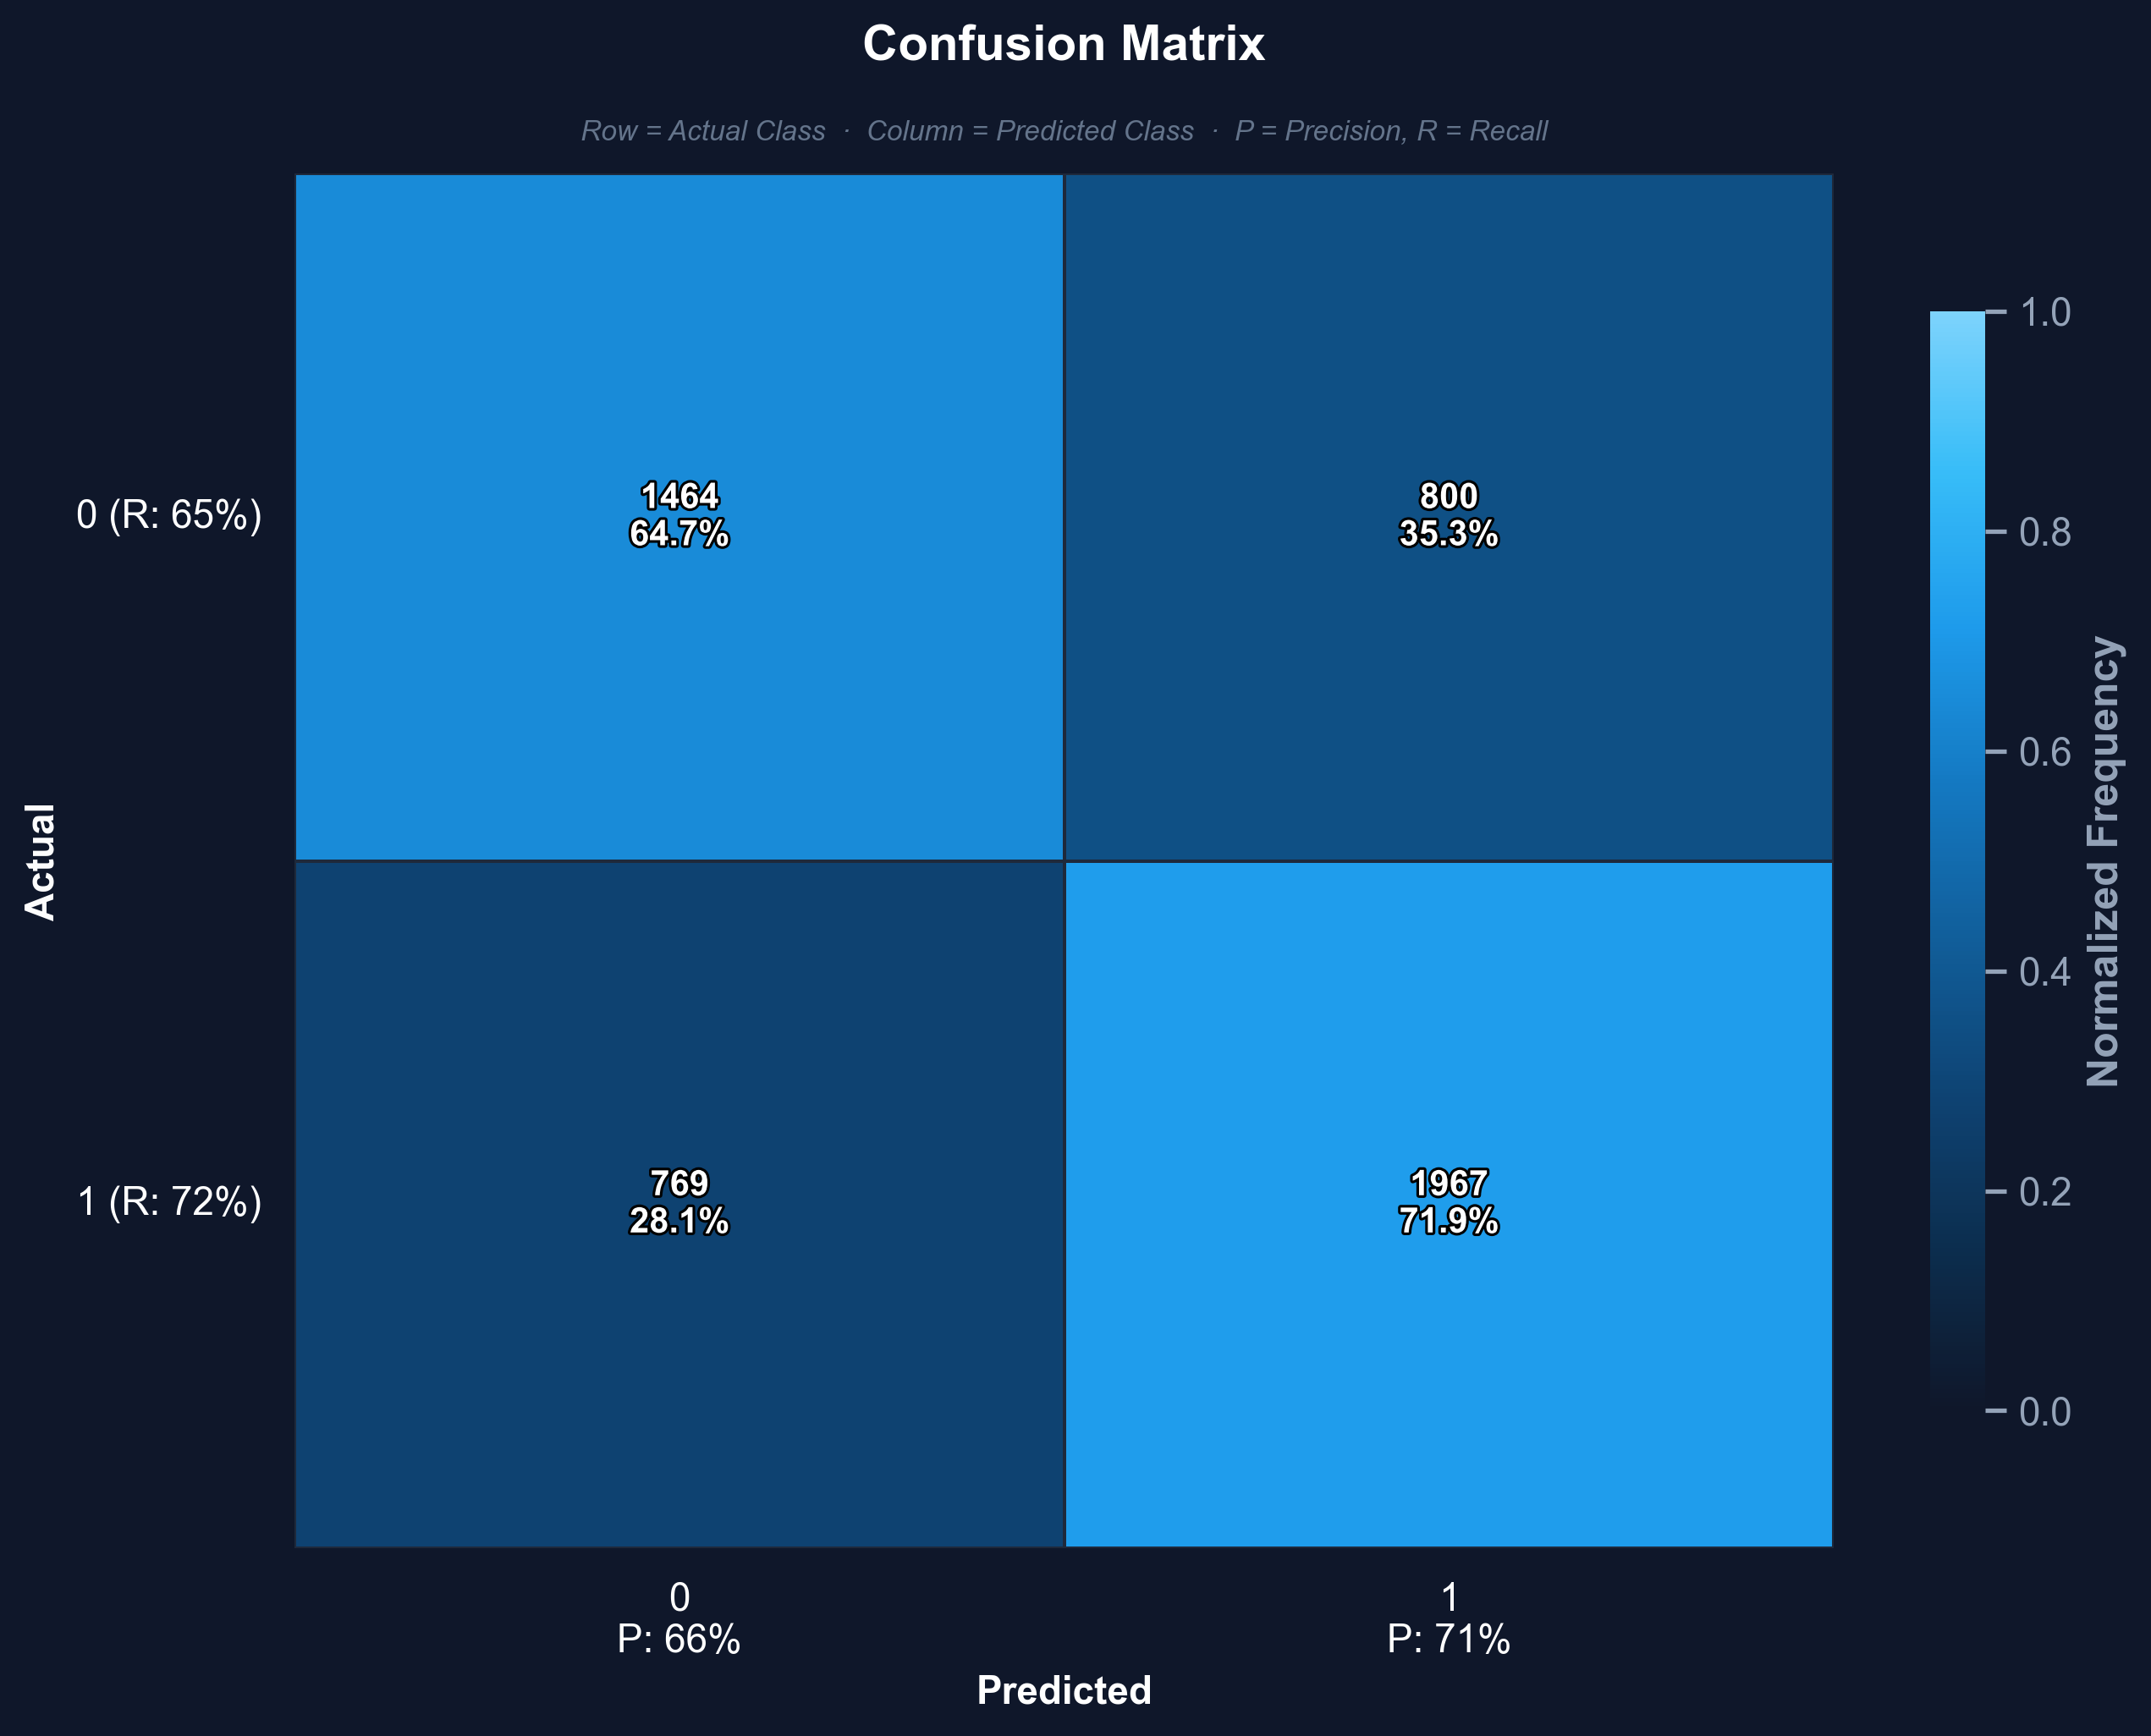
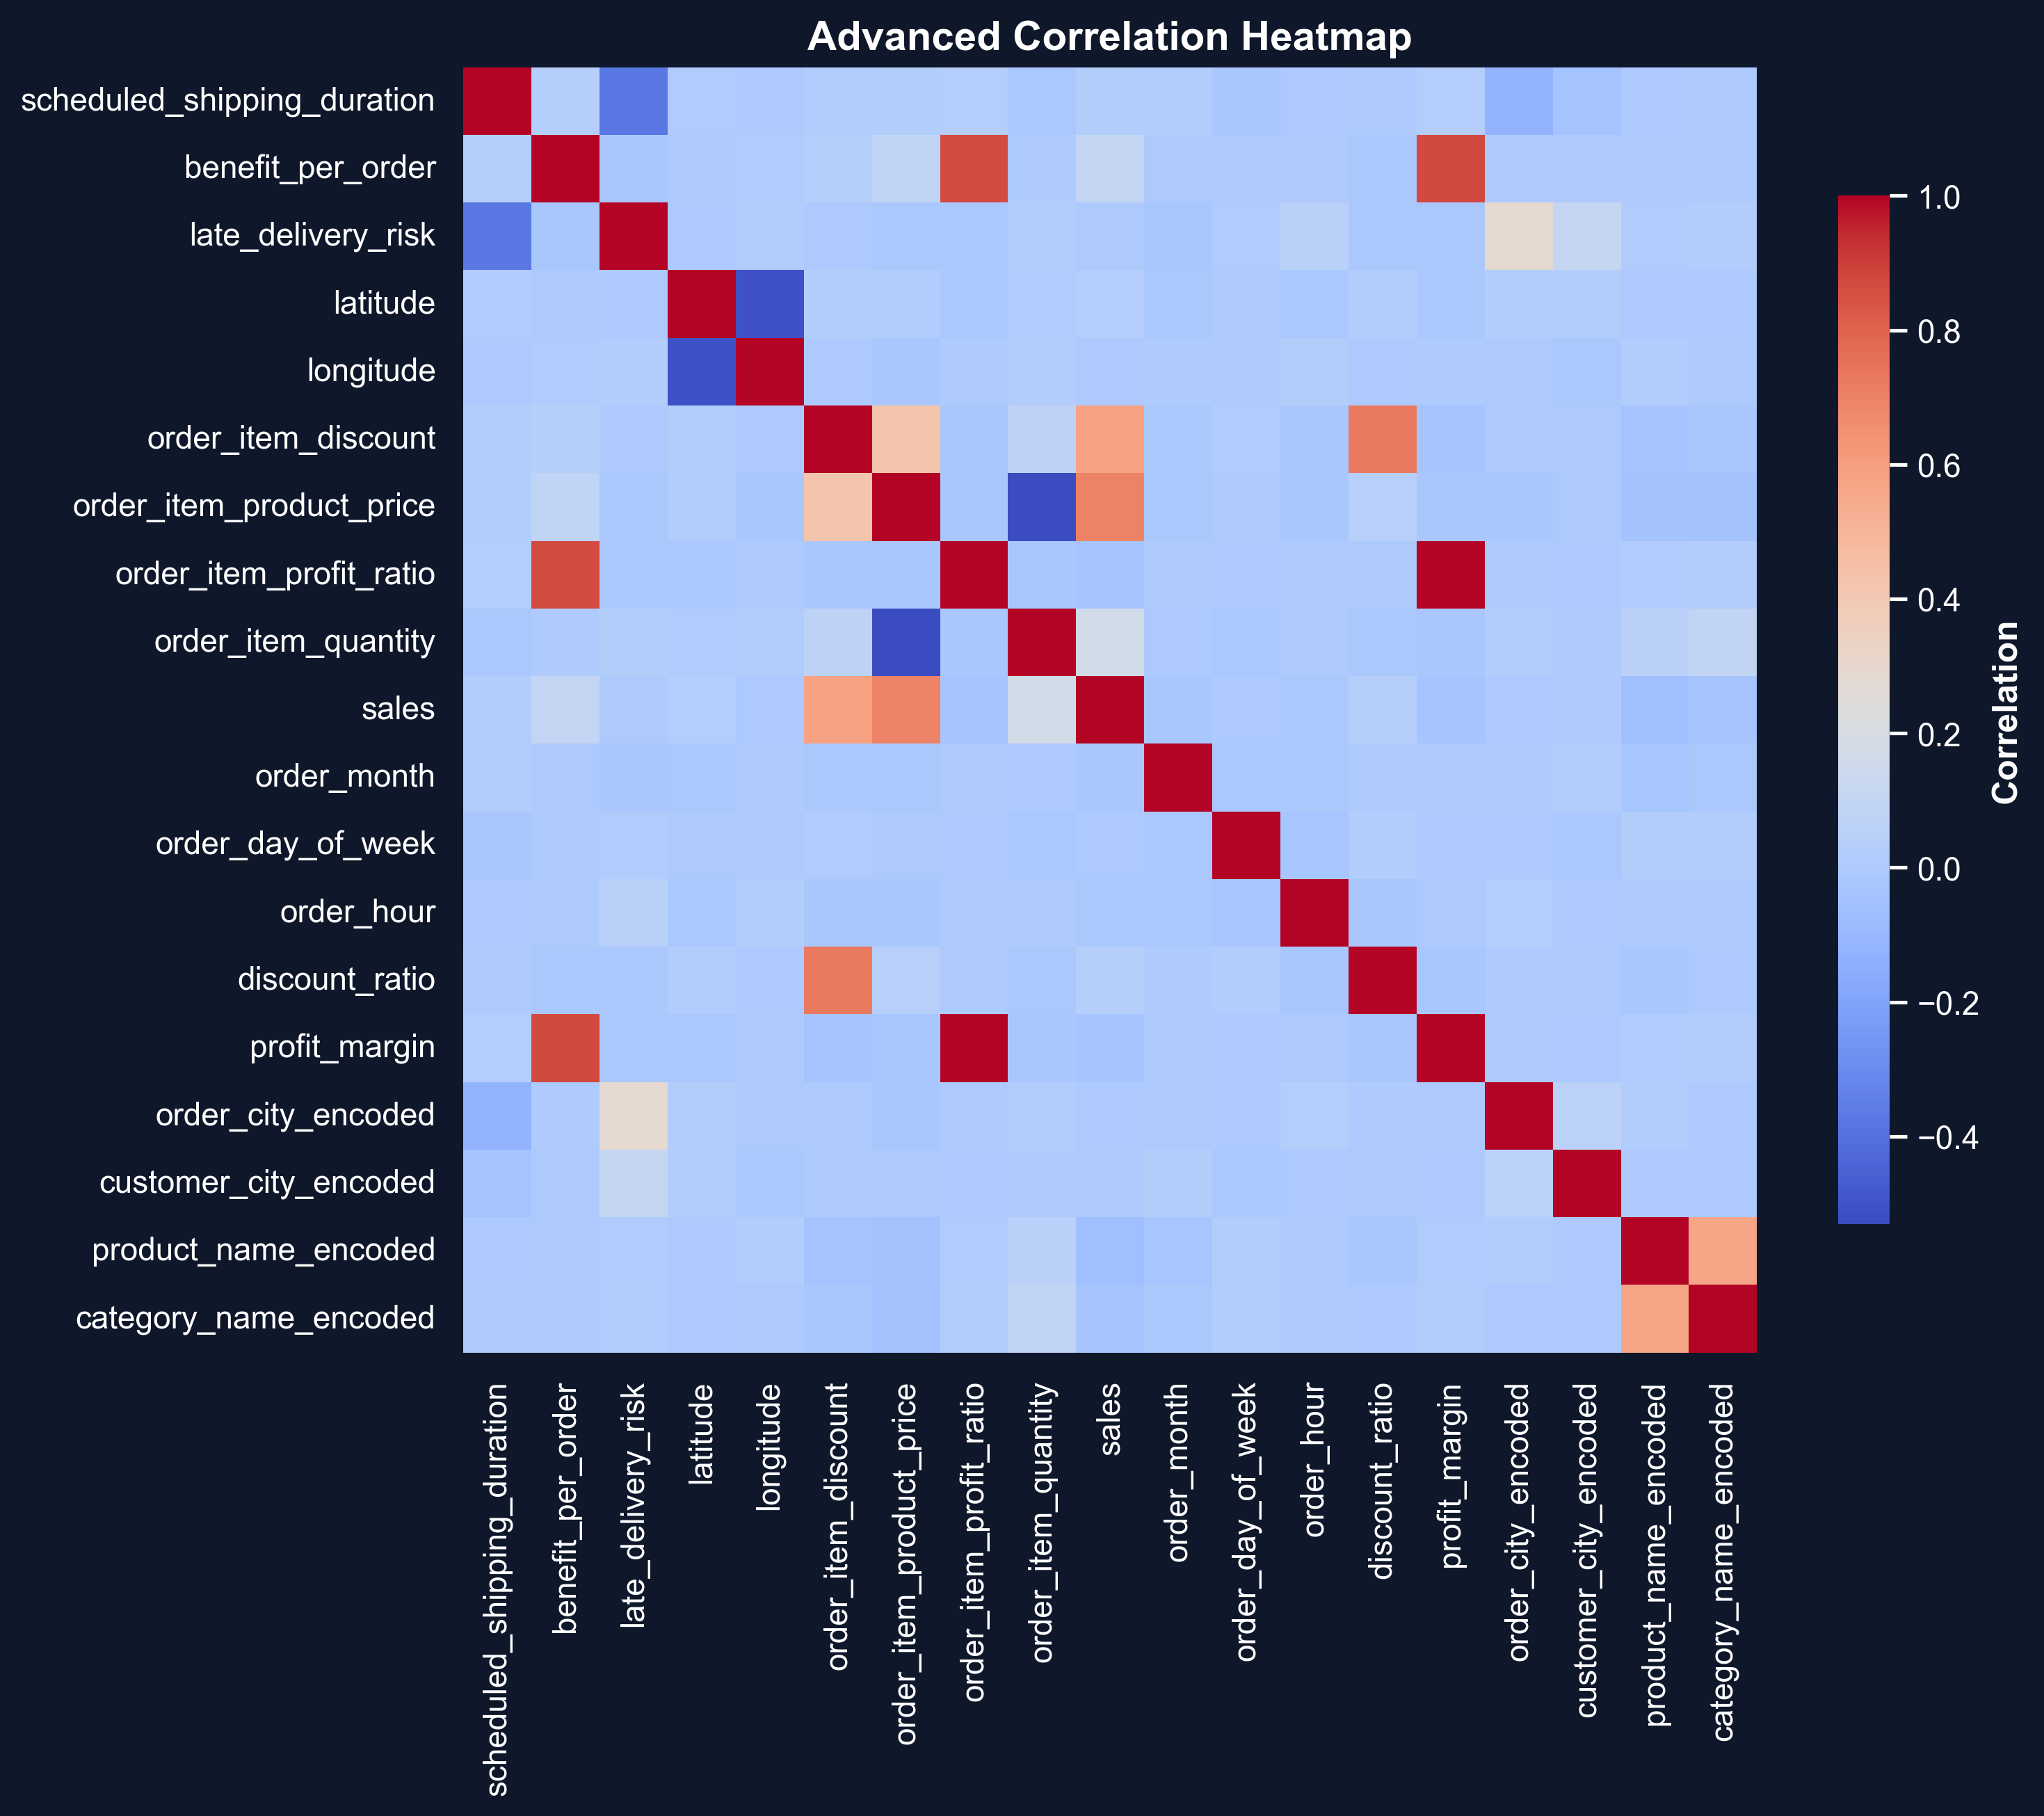
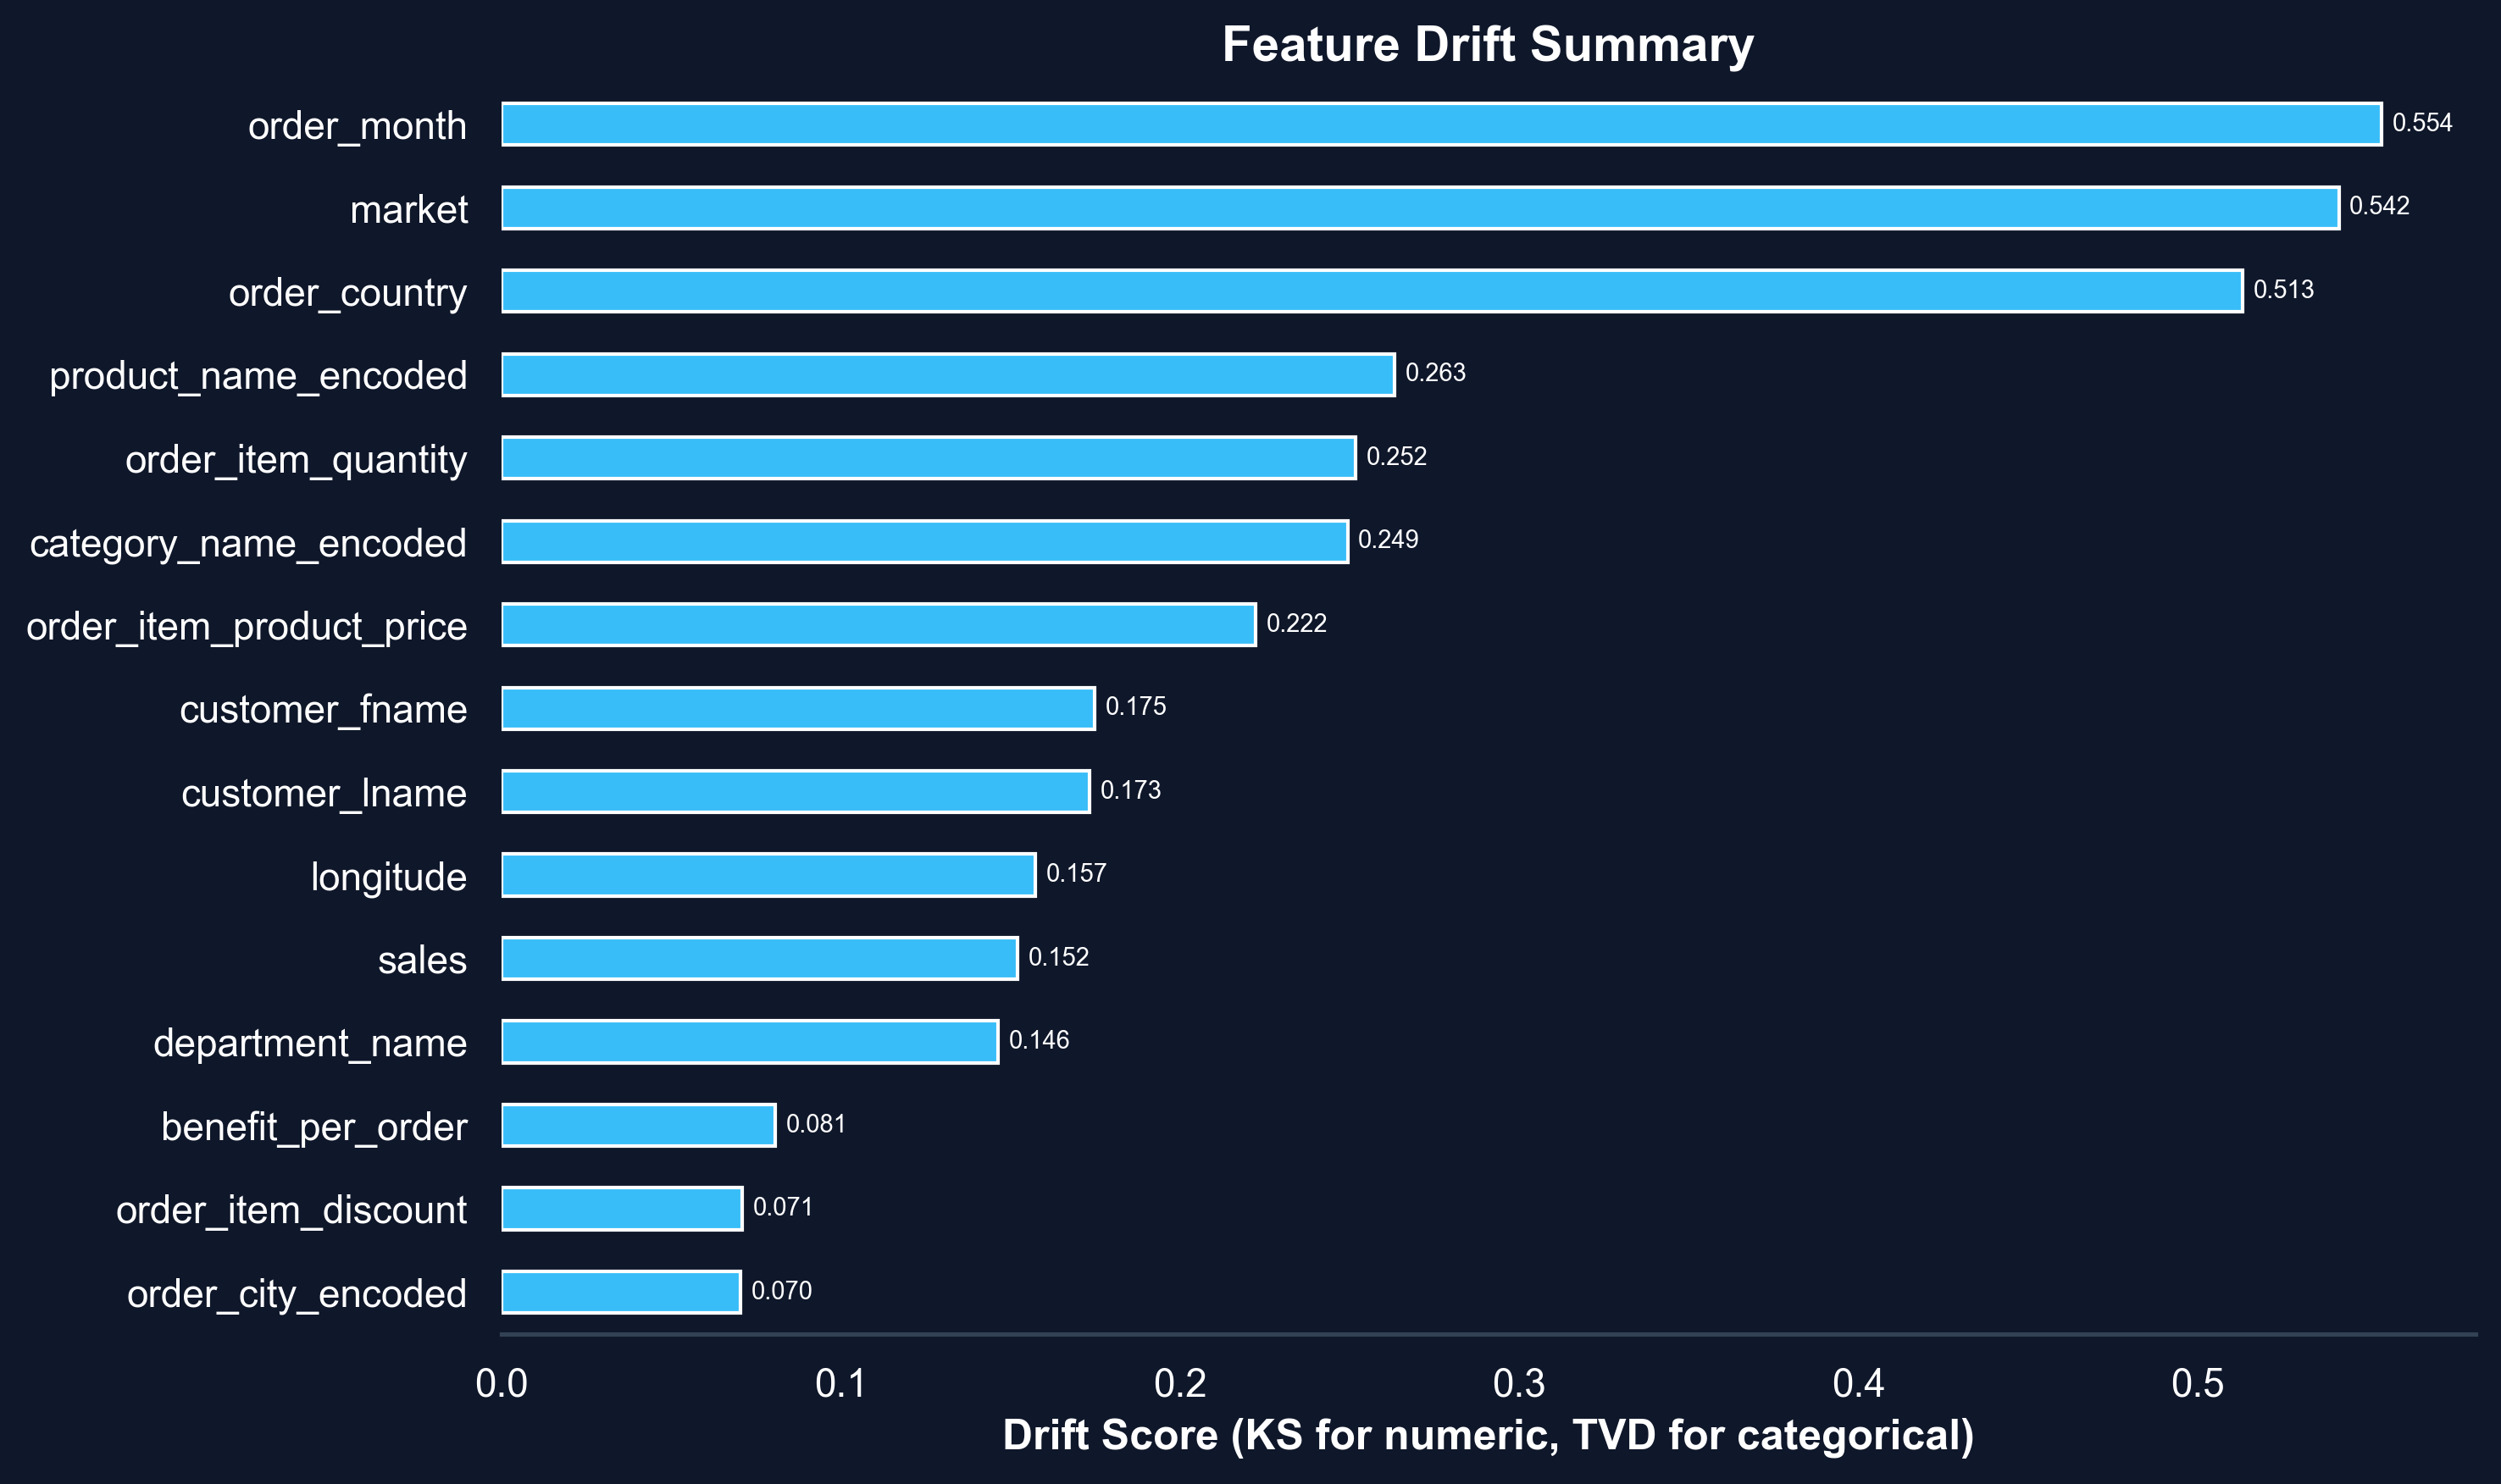
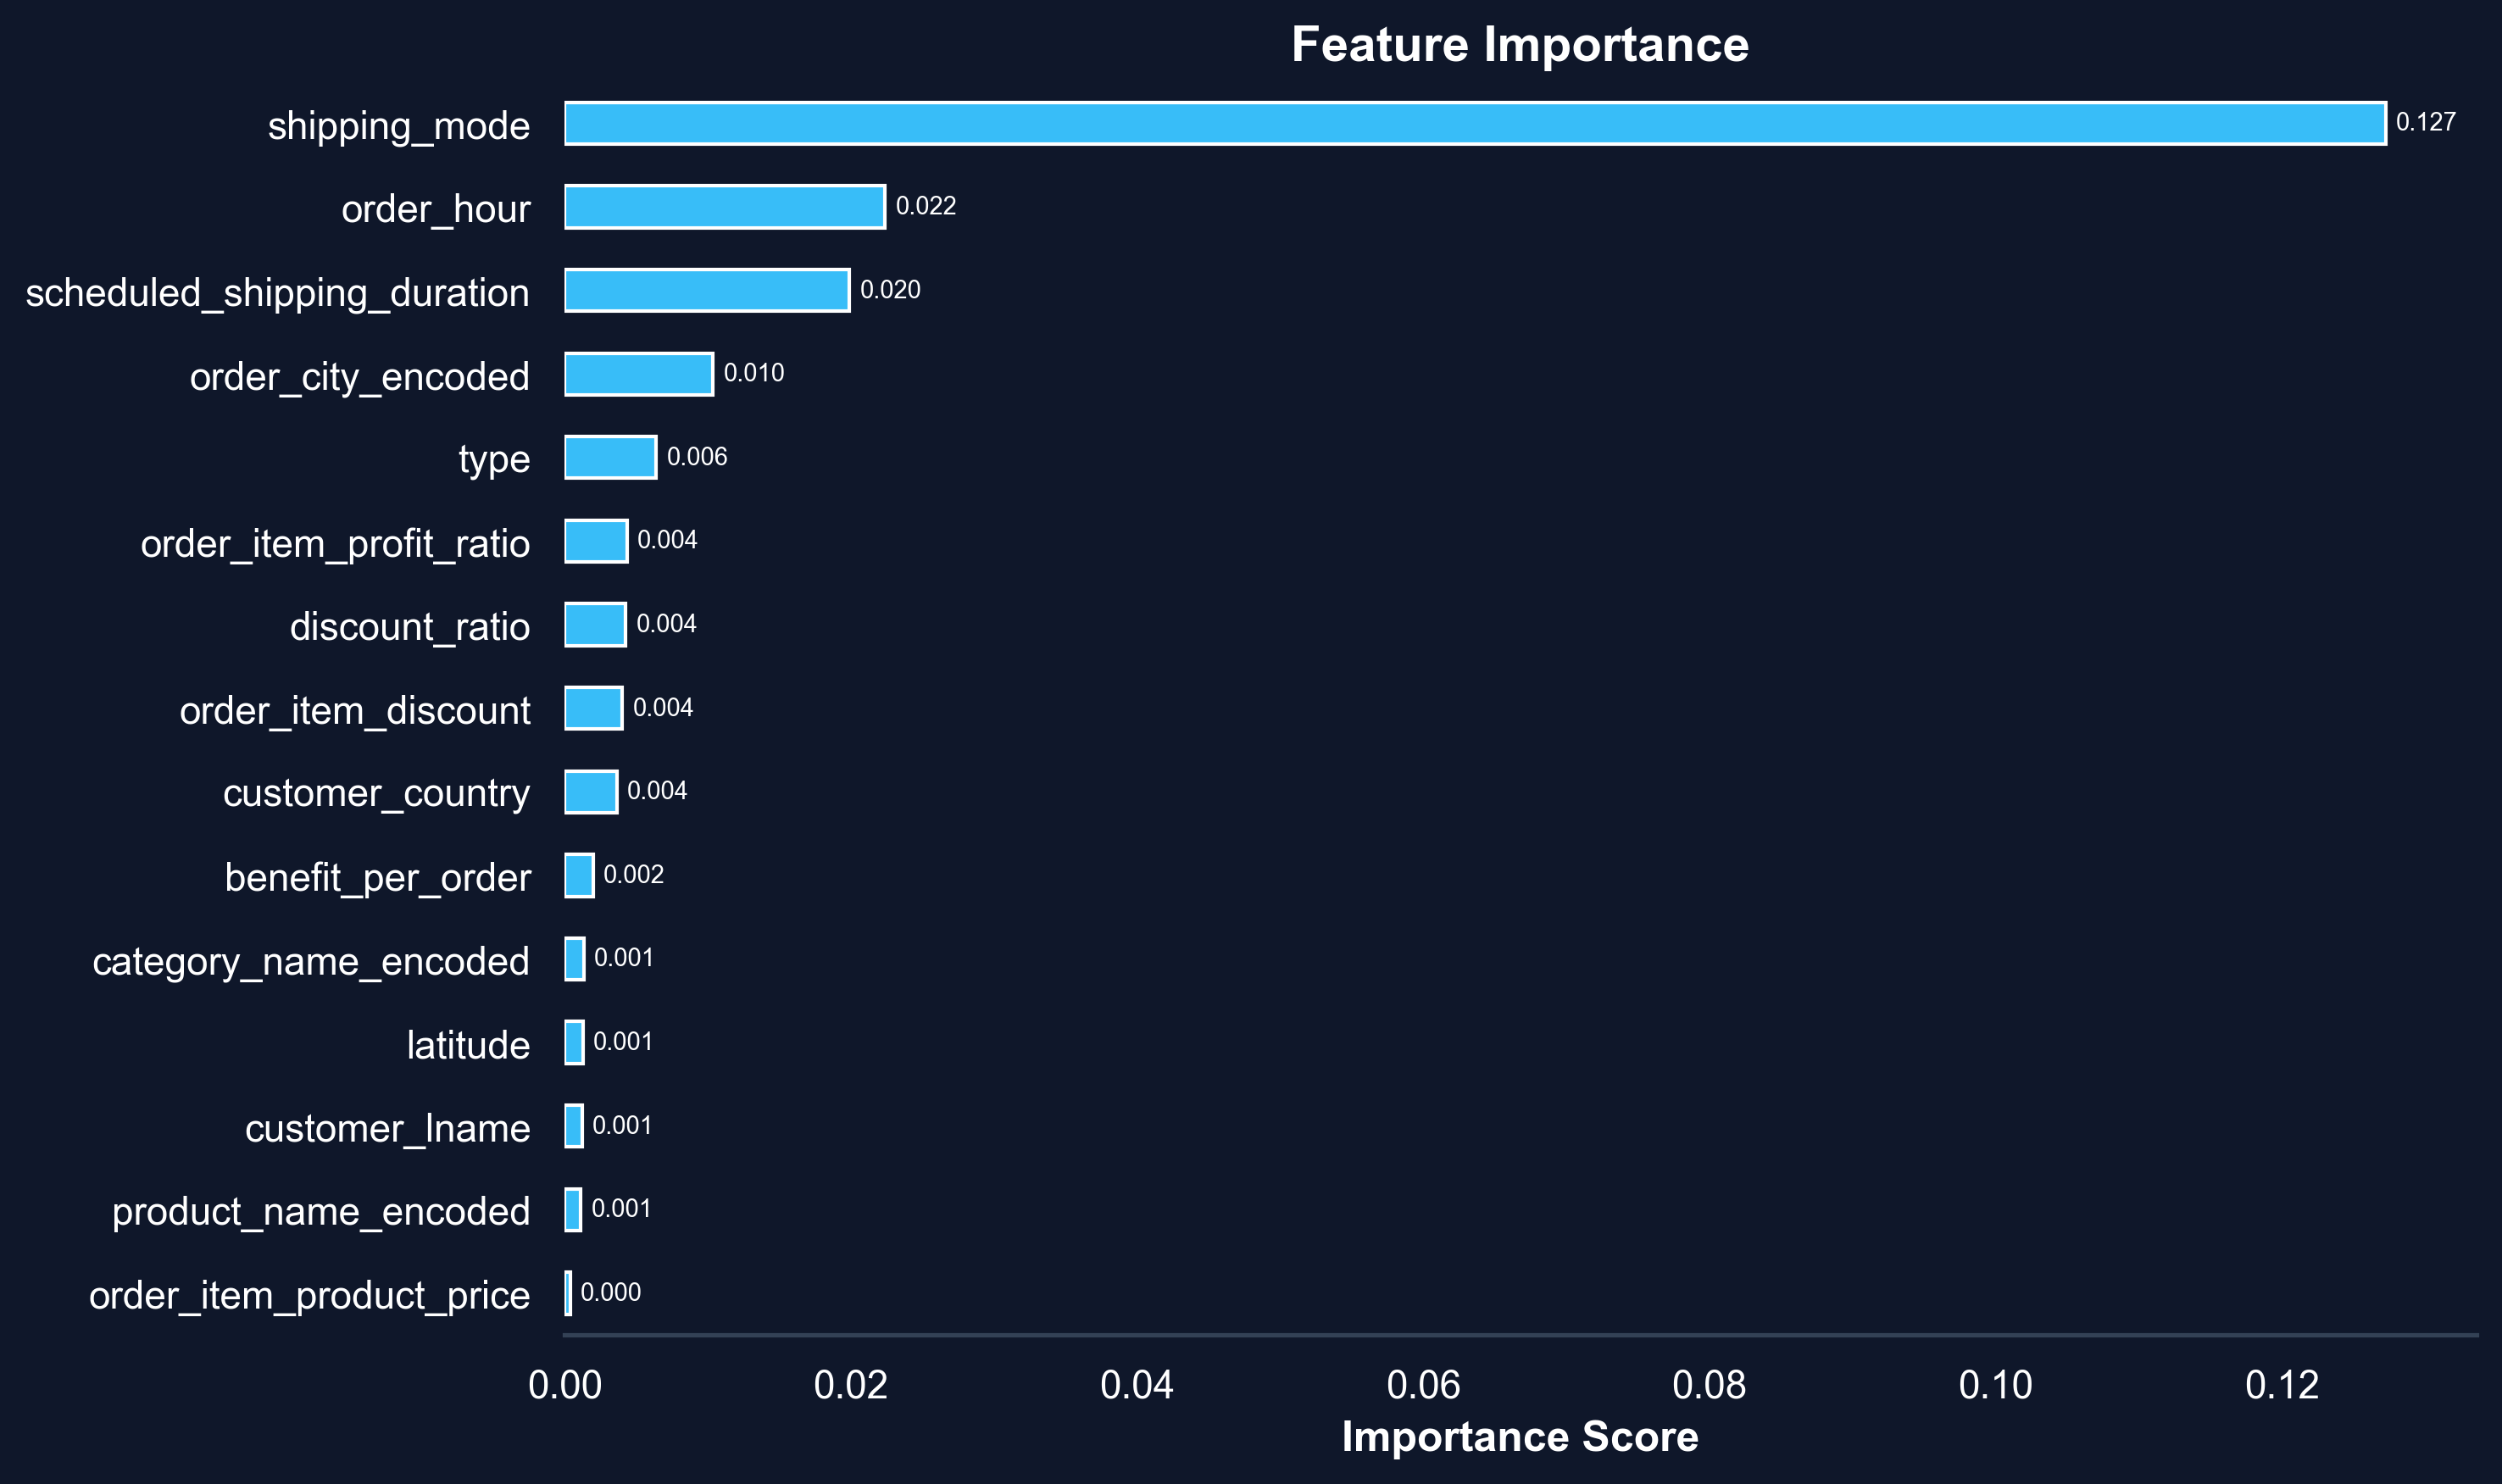
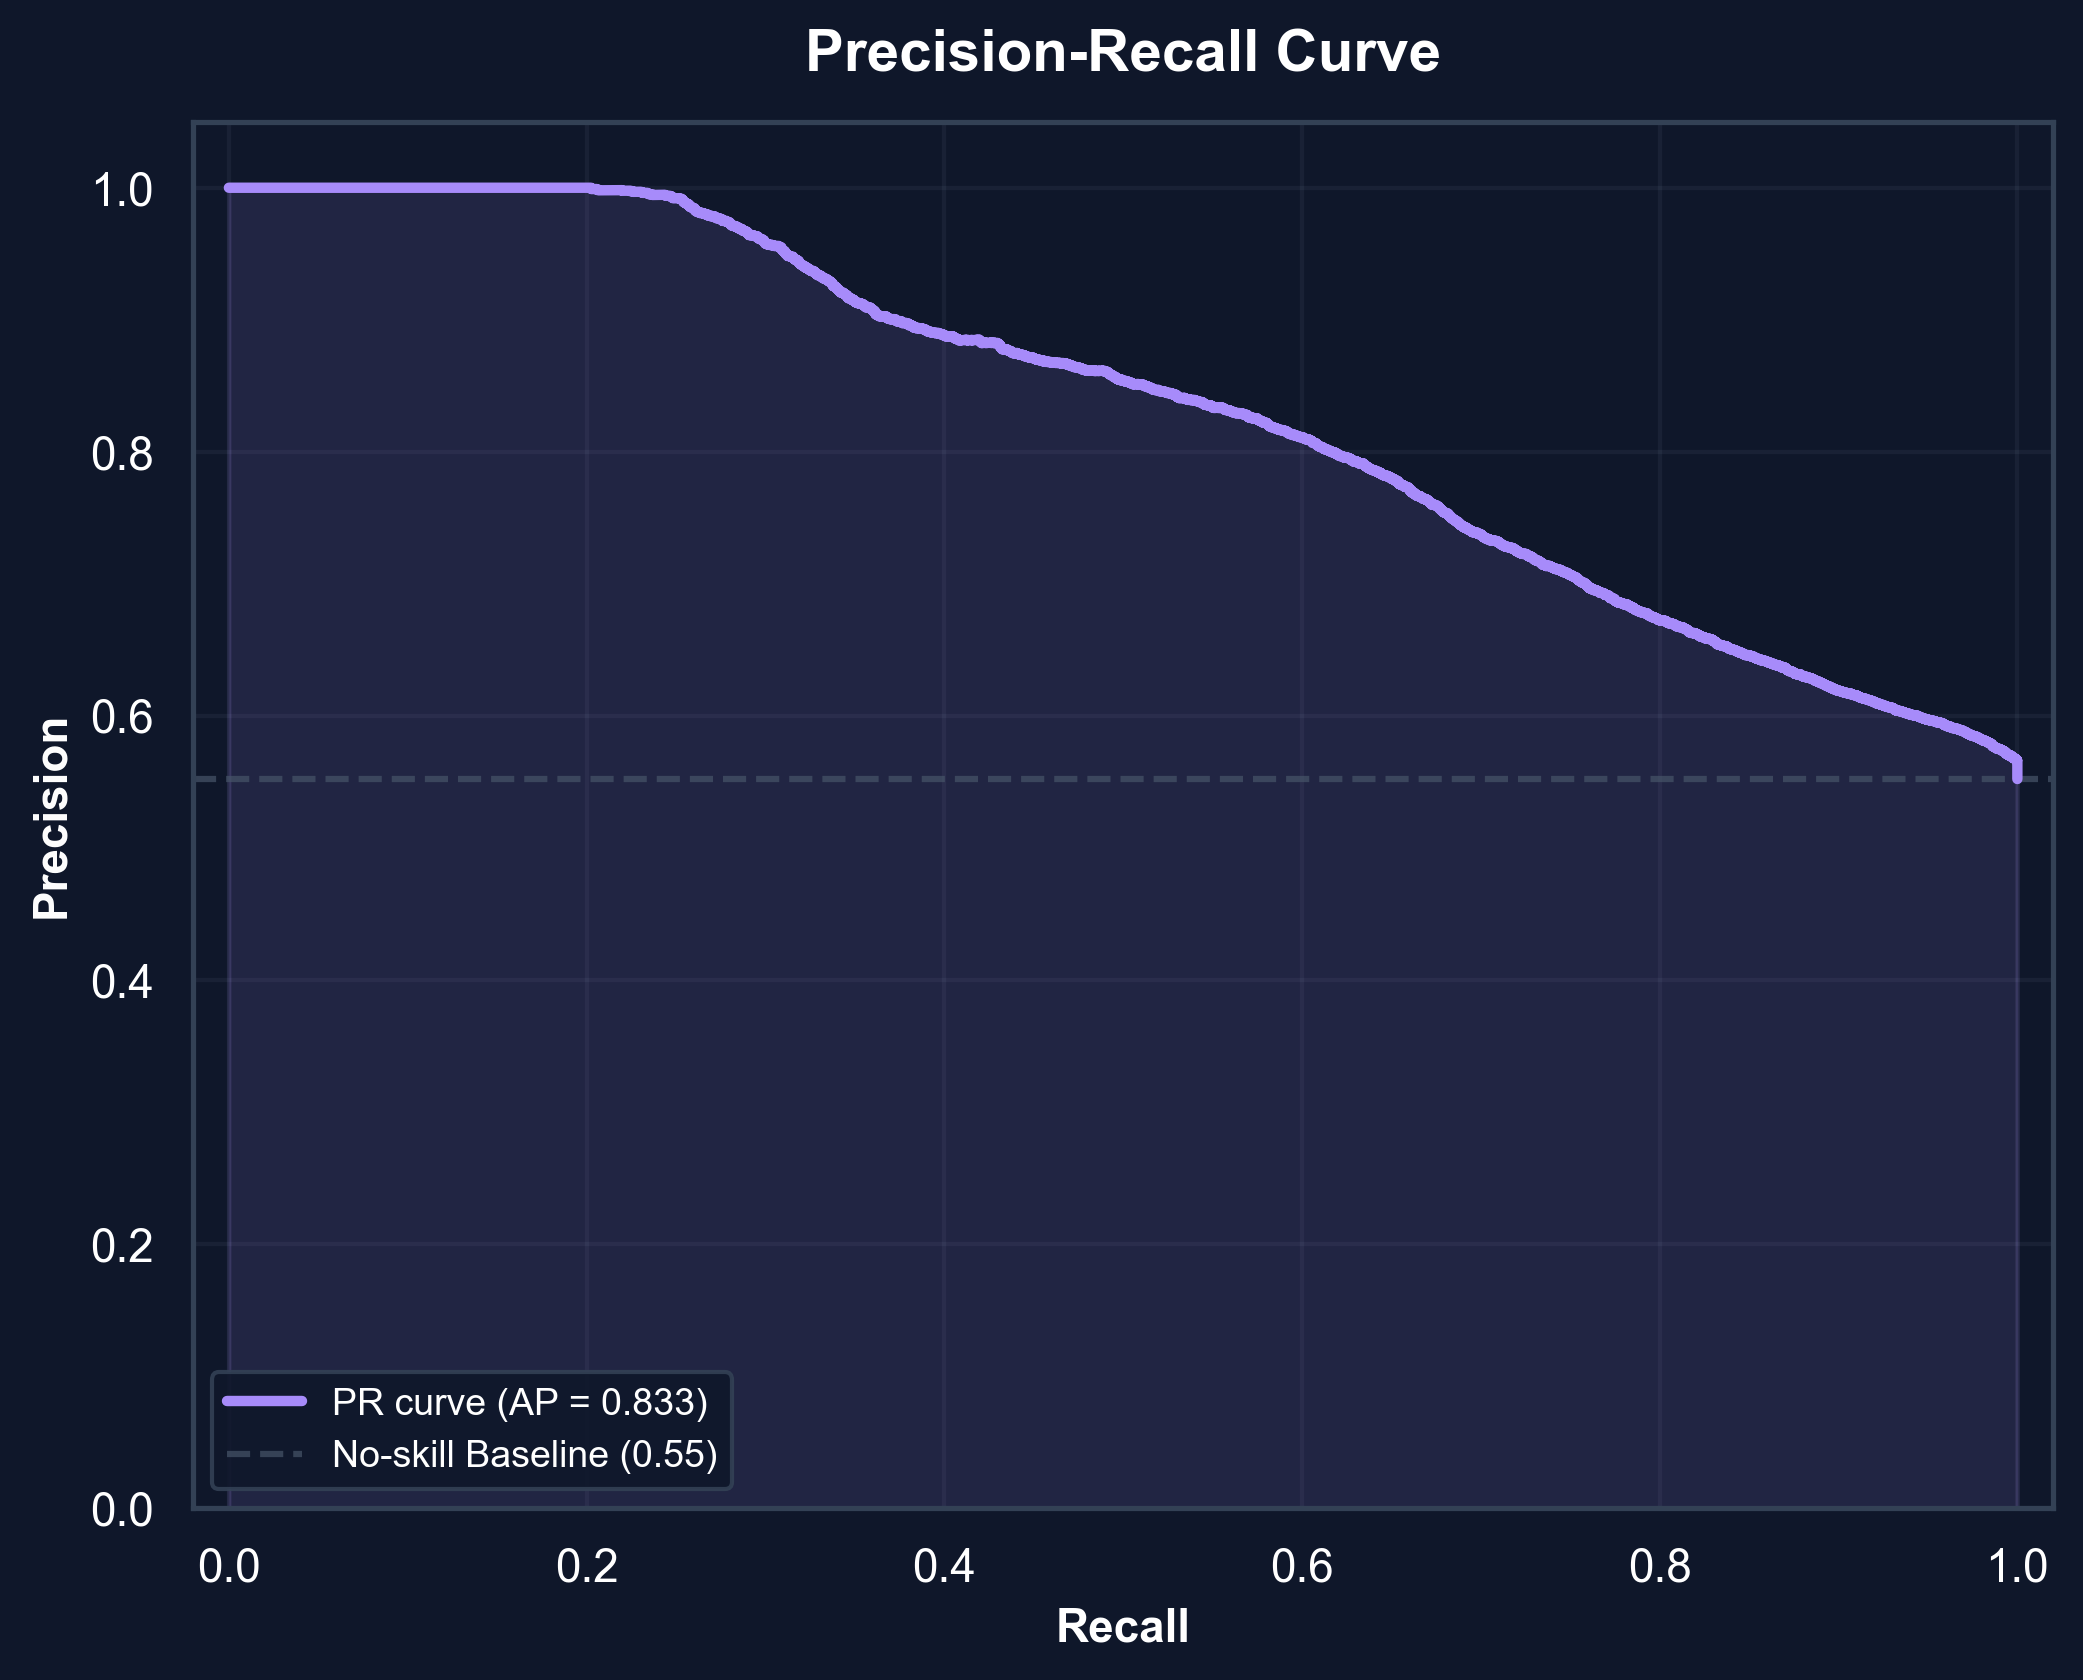
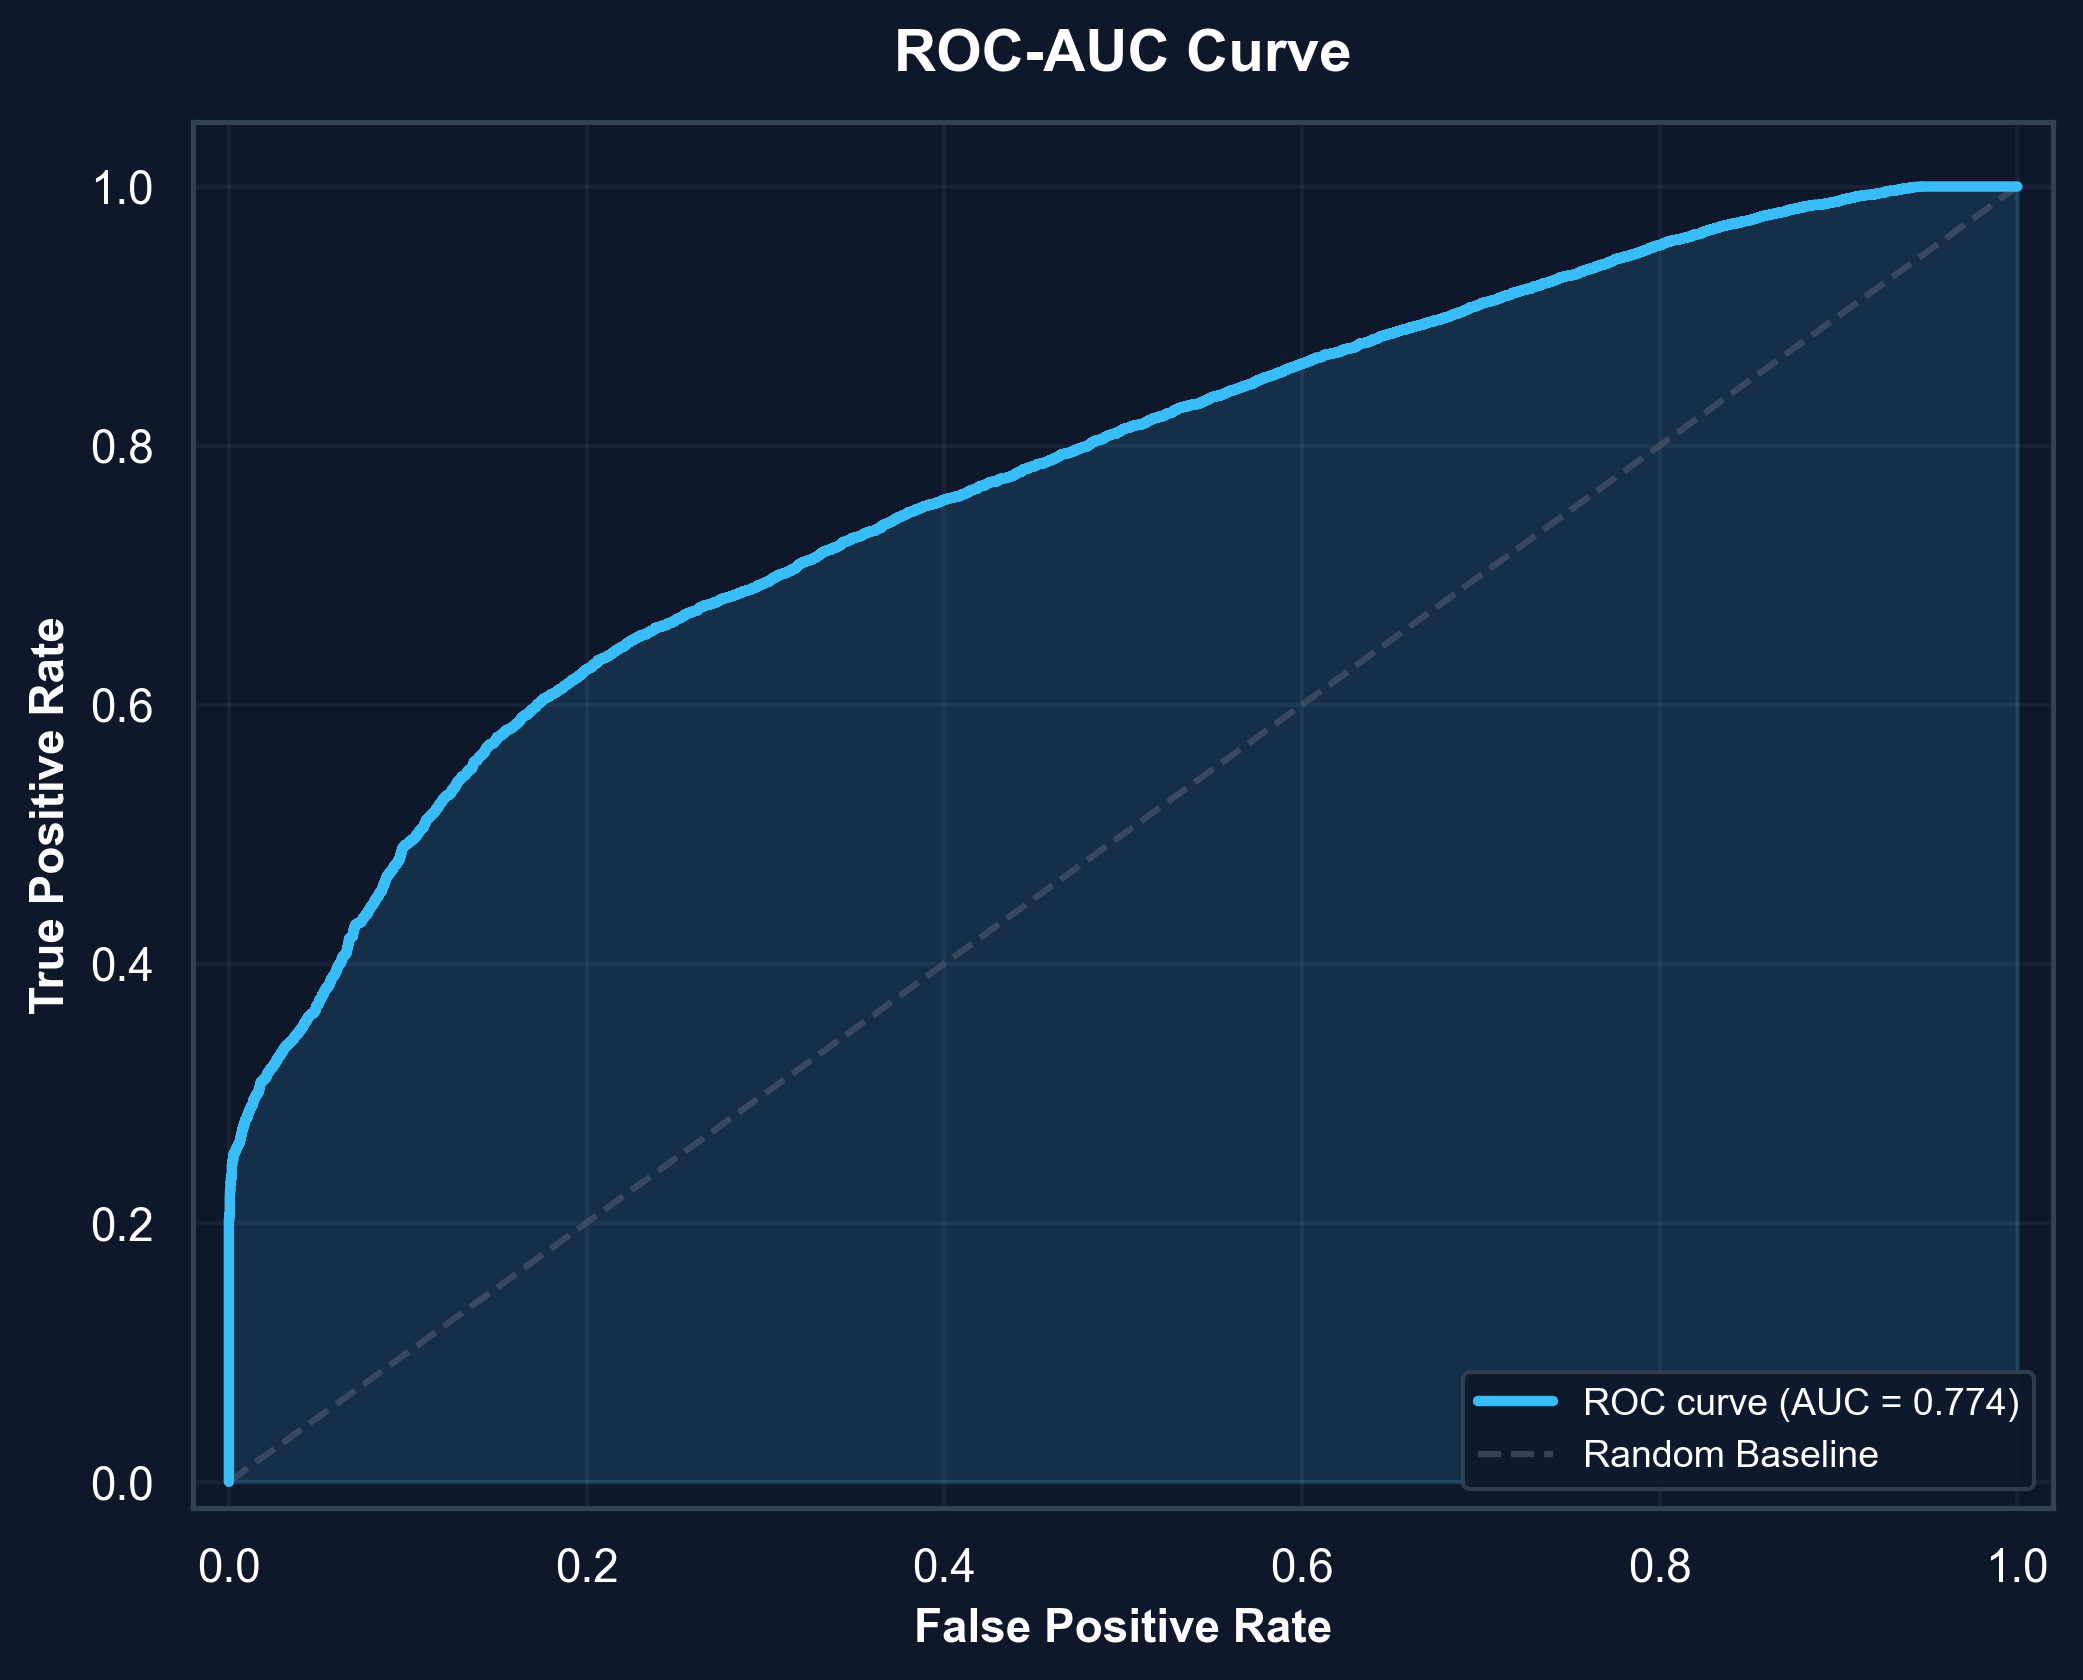
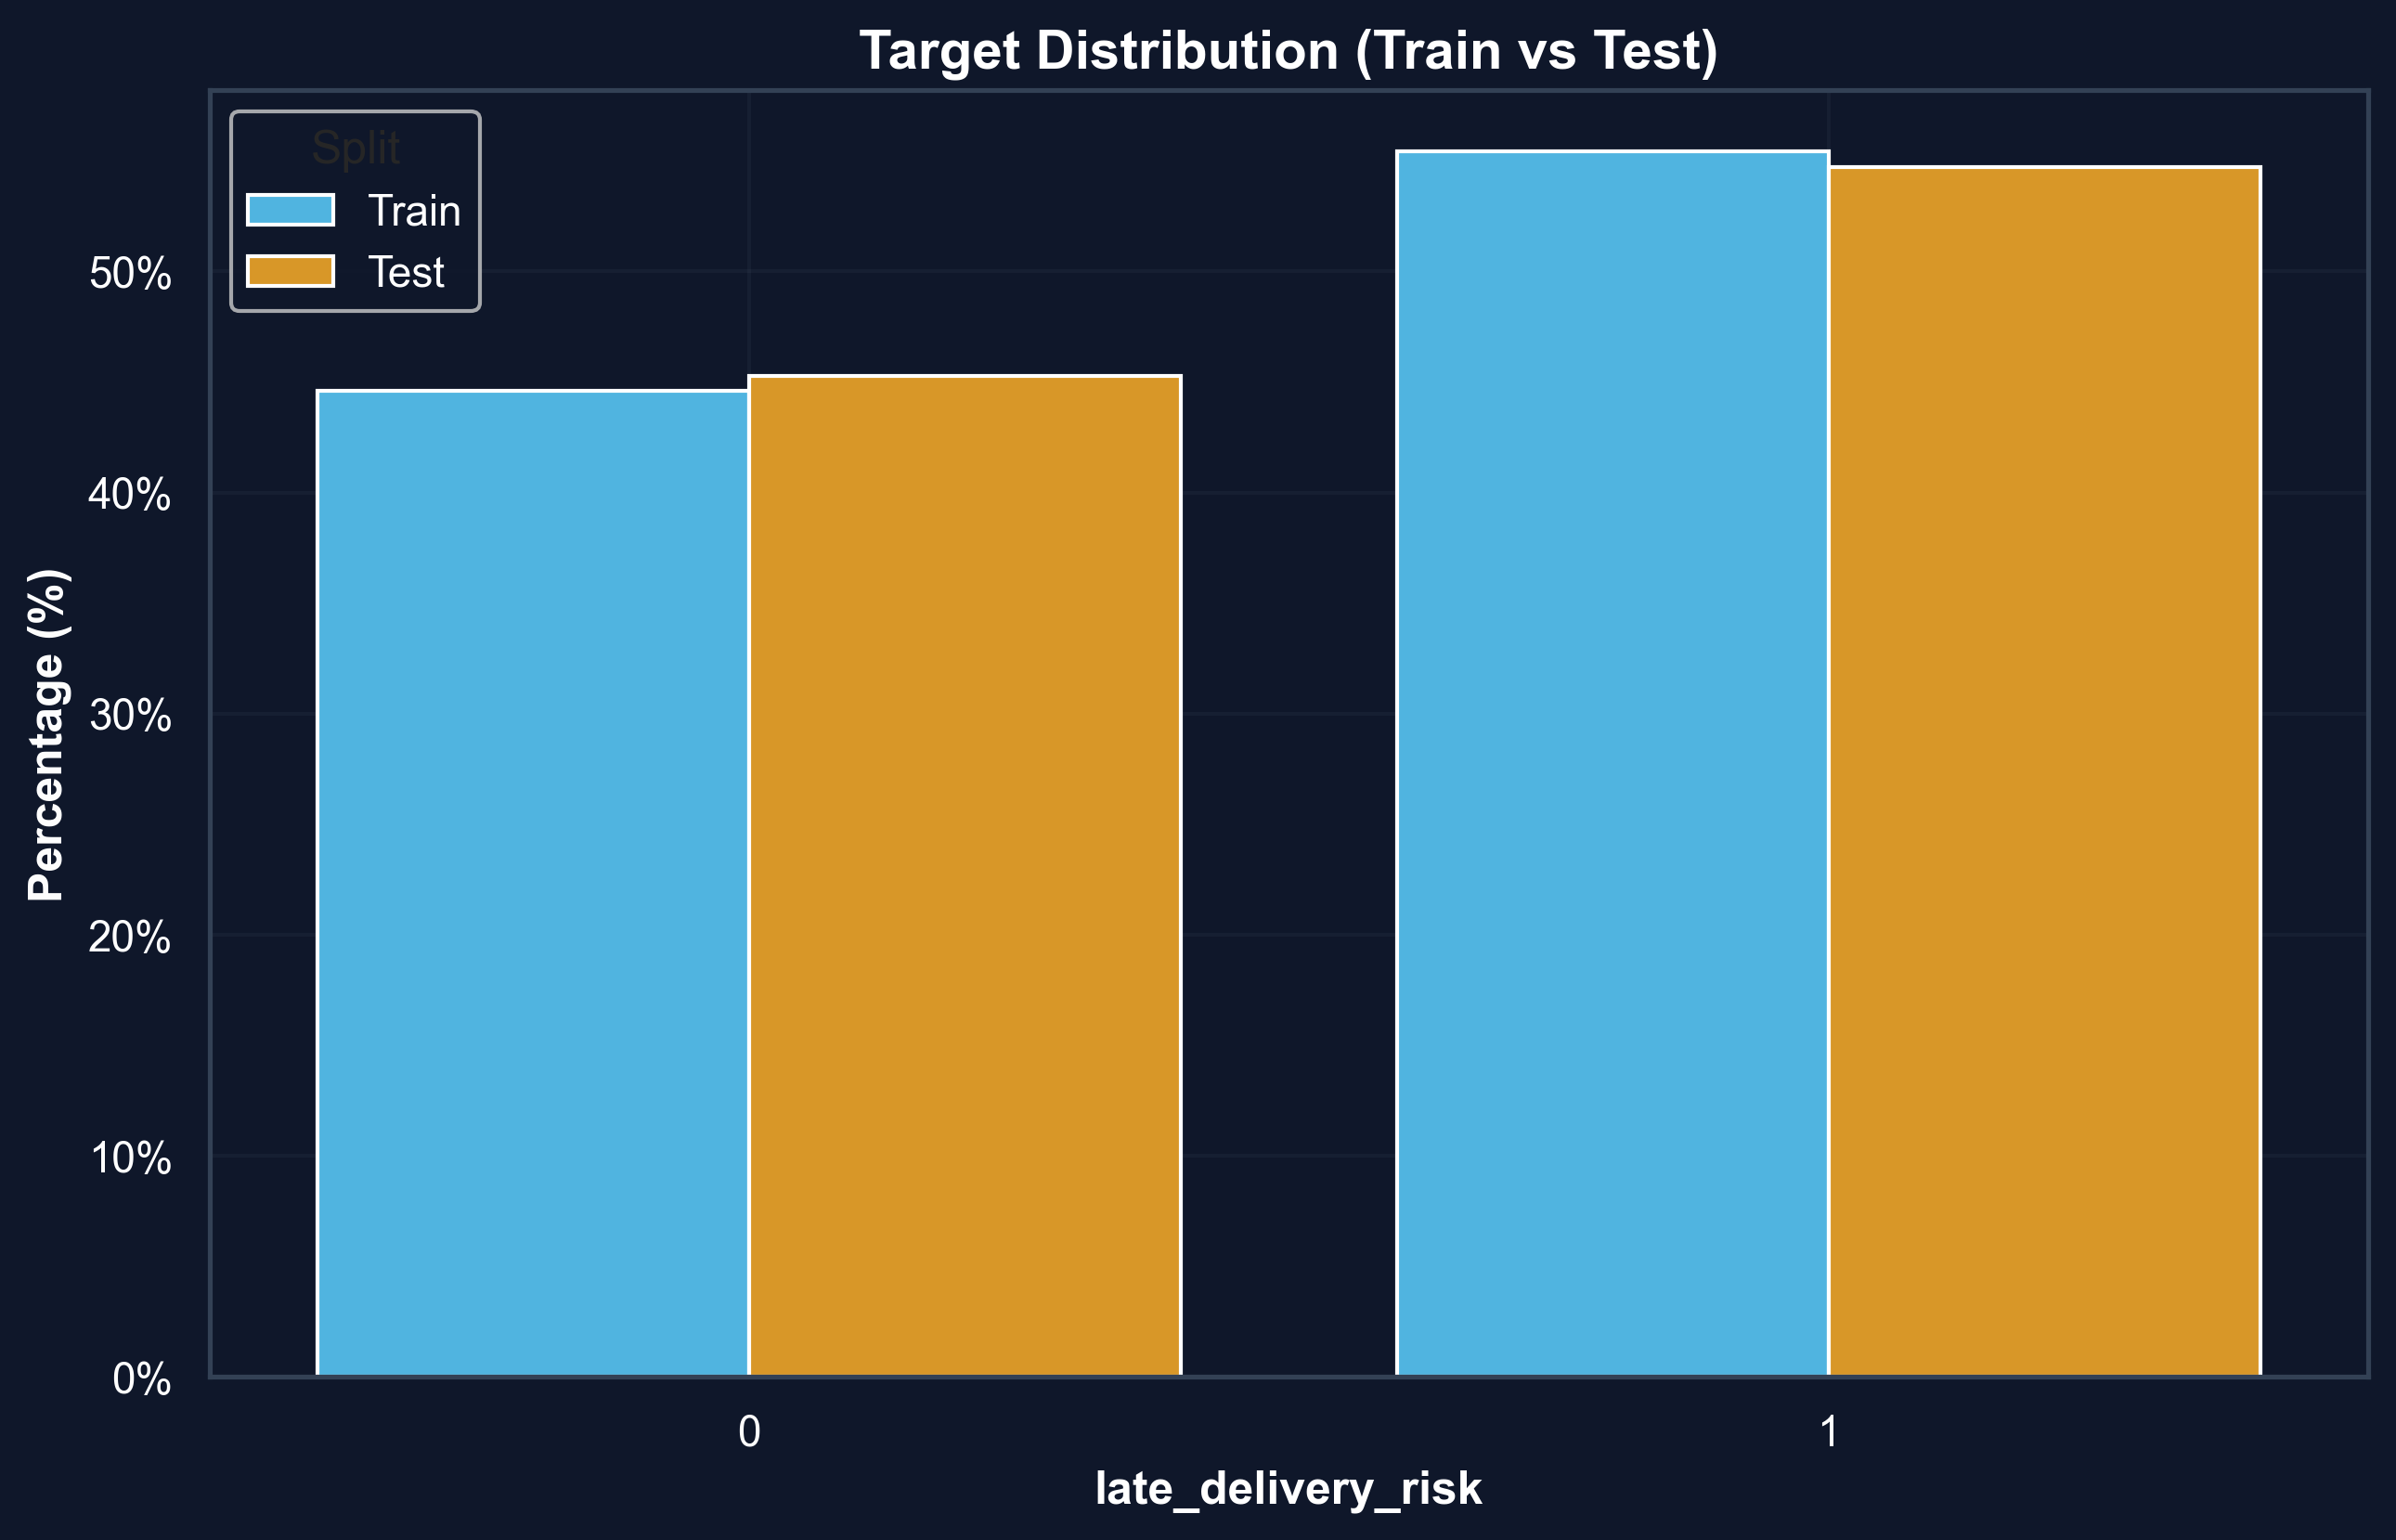

In [2]:
from ml_engine import AutoMLFactory

factory = AutoMLFactory(AUTOML_CONFIG)
factory.execute_pipeline()

---
## 🔧 Step 3: Post-Training Optimization for Deployment (Optional)
If bagging or stacking was enabled, `refit_full()` re-trains the best model on 100% of the data.
`persist()` loads models into RAM for faster inference. Only for server deployment. Update the engine first for this function.

Documentation : https://auto.gluon.ai/stable/tutorials/tabular/advanced/tabular-deployment.html

> **Note**: Only applicable when `num_bag_folds` or `auto_stack` were configured.

In [3]:
# Uncomment below for post-training optimization:
# factory._post_training_optimization()

---
## ✅ Run Summary

| Artifact | Location |
|:---|:---|
| Trained Models | `{base_output_dir}/models/` |
| Visualization Plots | `{base_output_dir}/plots/` |
| MLflow Tracking | `{base_output_dir}/mlruns/` |
| Batch Predictions | `{base_output_dir}/predictions/` |

All artifacts are portable. Copy the entire `base_output_dir` folder to share or deploy.